# Track jitter / spike / drop-out examples

Produces three figures for the **bridge subsection** between §3.4
(Behavioural indicators) and §3.5 (Data processing pipeline) in
`main.tex`. The figures substantiate the three measurement artefacts
listed there:

1. **Velocity spikes** (single-frame stereo-match errors).
2. **Positional jitter** on stationary tracks.
3. **Tracking drop-outs** (short gaps mid-track).

Each figure is produced from real `flight_tracks.csv` data, not
synthetic. The notebook picks a representative day-system folder
(set in the config cell) and automatically identifies the track with
the largest frame-to-frame velocity spike.


In [12]:
# ── imports + load ──
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Match the preprocessing thresholds in multi_day_pipeline_v3.ipynb
FPS               = 60.0       # PATS-C frame rate
MAX_BIO_VELOCITY  = 7.0        # m/s — Goulson 2010 biological max
SMOOTH_WINDOW     = 5          # frames for the centred rolling mean
MIN_TRACK_FRAMES  = 10

DATA_BASE = Path("../../../data/flight_data")
FOLDER    = "2026-05-15_system_900"   # change to inspect a different day-system

ft = pd.read_csv(DATA_BASE / FOLDER / "flight_tracks.csv",
                 usecols=["detection_uid", "elapsed", "pos_valid_insect",
                          "posX_insect", "posY_insect", "posZ_insect"])
ft = ft[ft["pos_valid_insect"] == 1]
print(f"Loaded {len(ft):,} valid frames across {ft['detection_uid'].nunique()} tracks "
      f"from {FOLDER}")


Loaded 206,246 valid frames across 1073 tracks from 2026-05-15_system_900


## 1. Find the most spike-y track

For every track, compute the maximum frame-to-frame speed. Sort
descending and pick the worst — that's the track most likely to
illustrate spike + jitter behaviour in a single figure.

In [13]:
# ── identify a representative jittery track ──
def max_frame_velocity(group):
    g = group.sort_values("elapsed")
    coords = g[["posX_insect", "posY_insect", "posZ_insect"]].values
    if len(coords) < 5:
        return np.nan
    dt = np.diff(g["elapsed"].values)
    if np.any(dt <= 0):
        return np.nan
    return float(np.nanmax(np.linalg.norm(np.diff(coords, axis=0), axis=1) / dt))

per_track_max_v = (ft.groupby("detection_uid")
                     .apply(max_frame_velocity, include_groups=False)
                     .dropna()
                     .sort_values(ascending=False))

print("Top 10 tracks by maximum frame-to-frame velocity (m/s):")
print(per_track_max_v.head(10).round(1).to_string())

TARGET_UID = int(per_track_max_v.index[0])
print(f"\nPicked track {TARGET_UID} (max frame-to-frame speed "
      f"{per_track_max_v.iloc[0]:.1f} m/s) for the example figures.")


Top 10 tracks by maximum frame-to-frame velocity (m/s):
detection_uid
2570256    431.1
2568813    388.4
2569599    362.1
2575034    317.8
2575688    301.5
2573178    278.8
2574754    244.6
2568221    231.8
2569711    205.2
2571498    200.1

Picked track 2570256 (max frame-to-frame speed 431.1 m/s) for the example figures.


## 2. Flight path of the jittery track — scatter on line

Both projections (top-down `xy` and side `xz`). The line is drawn
faintly so it can be overlaid; the individual frame positions are
plotted as scatter points coloured by time. Sudden long line segments
between consecutive points are the visible signature of a spike.

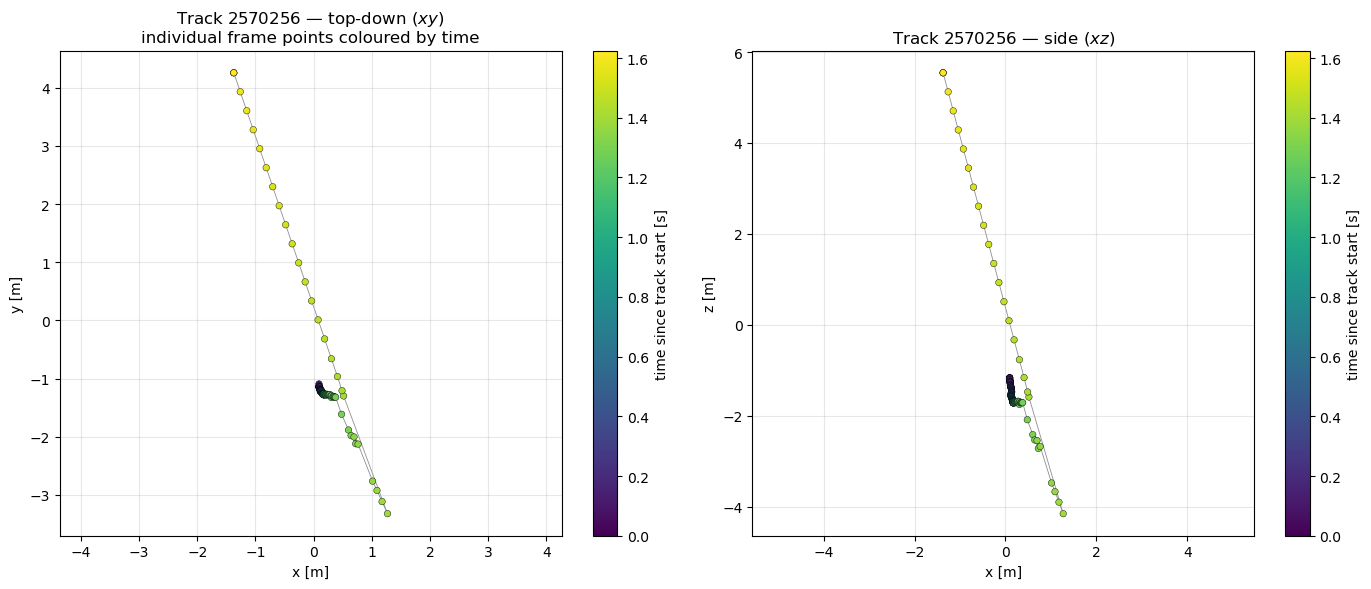

In [14]:
# ── plot the trajectory of the chosen track ──
trk = (ft[ft["detection_uid"] == 2575688]
         .sort_values("elapsed").reset_index(drop=True))
x = trk["posX_insect"].values
y = trk["posY_insect"].values
z = trk["posZ_insect"].values
t = trk["elapsed"].values - trk["elapsed"].iloc[0]

fig, (axxy, axxz) = plt.subplots(1, 2, figsize=(14, 6))

# top-down xy
axxy.plot(x, y, "-", color="#444", linewidth=0.6, alpha=0.6, zorder=1)
sc1 = axxy.scatter(x, y, c=t, cmap="viridis", s=22,
                   edgecolor="black", linewidth=0.3, zorder=3)
axxy.set_xlabel("x [m]"); axxy.set_ylabel("y [m]")
axxy.set_title(f"Track {TARGET_UID} — top-down ($xy$)\n"
               f"individual frame points coloured by time")
plt.colorbar(sc1, ax=axxy, label="time since track start [s]")
axxy.set_aspect("equal", adjustable="datalim")
axxy.grid(alpha=0.3)

# side xz
axxz.plot(x, z, "-", color="#444", linewidth=0.6, alpha=0.6, zorder=1)
sc2 = axxz.scatter(x, z, c=t, cmap="viridis", s=22,
                   edgecolor="black", linewidth=0.3, zorder=3)
axxz.set_xlabel("x [m]"); axxz.set_ylabel("z [m]")
axxz.set_title(f"Track {TARGET_UID} — side ($xz$)")
plt.colorbar(sc2, ax=axxz, label="time since track start [s]")
axxz.set_aspect("equal", adjustable="datalim")
axxz.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 3. Frame-to-frame velocity profile

Same track, plotted as speed-vs-time. The red dashed line at the
biological maximum (Goulson 2010) marks the threshold above which any
single-frame speed is physically implausible and must be a tracking
artefact rather than real bee motion.

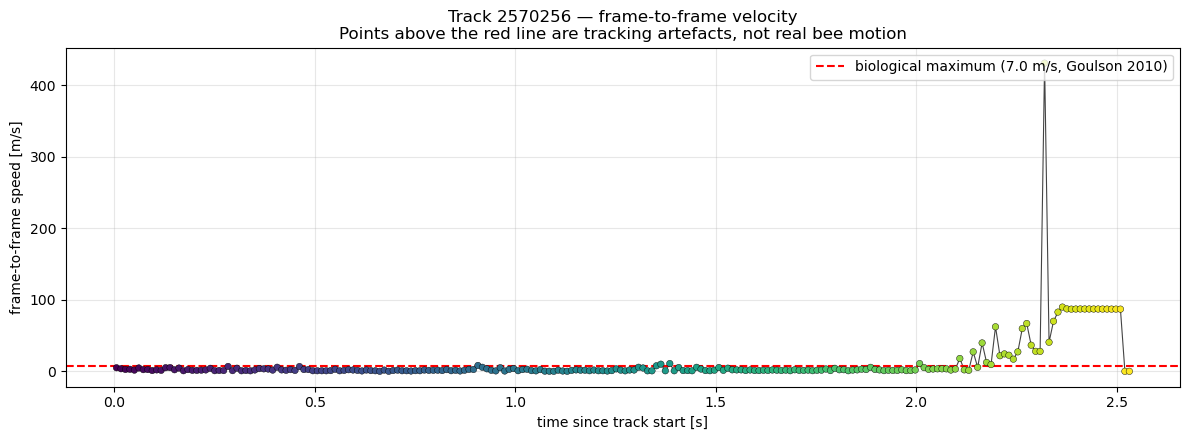

Track has 39 frame(s) with speed > 7.0 m/s out of 228 frame-to-frame intervals.
Maximum observed frame-to-frame speed: 431.1 m/s.


In [4]:
# ── frame-to-frame velocity over time ──
dt = np.diff(t)
speeds = np.linalg.norm(
    np.diff(trk[["posX_insect","posY_insect","posZ_insect"]].values, axis=0),
    axis=1
) / dt
mid_t = (t[:-1] + t[1:]) / 2

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(mid_t, speeds, "-", color="#444", linewidth=0.8)
ax.scatter(mid_t, speeds, c=mid_t, cmap="viridis", s=22,
           edgecolor="black", linewidth=0.3, zorder=3)
ax.axhline(MAX_BIO_VELOCITY, color="red", linestyle="--", linewidth=1.5,
           label=f"biological maximum ({MAX_BIO_VELOCITY} m/s, Goulson 2010)")
ax.set_xlabel("time since track start [s]")
ax.set_ylabel("frame-to-frame speed [m/s]")
ax.set_title(f"Track {TARGET_UID} — frame-to-frame velocity\n"
             f"Points above the red line are tracking artefacts, not real bee motion")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

n_spikes = int((speeds > MAX_BIO_VELOCITY).sum())
print(f"Track has {n_spikes} frame(s) with speed > {MAX_BIO_VELOCITY} m/s "
      f"out of {len(speeds)} frame-to-frame intervals.")
print(f"Maximum observed frame-to-frame speed: {speeds.max():.1f} m/s.")


## 4. Before / after spike-heal + smooth

The same trajectory and velocity profile after the preprocessing step
described in §3.5: frames with speed > 7 m/s are set to NaN, linearly
interpolated, then the positions are smoothed with a centred 5-frame
rolling mean.

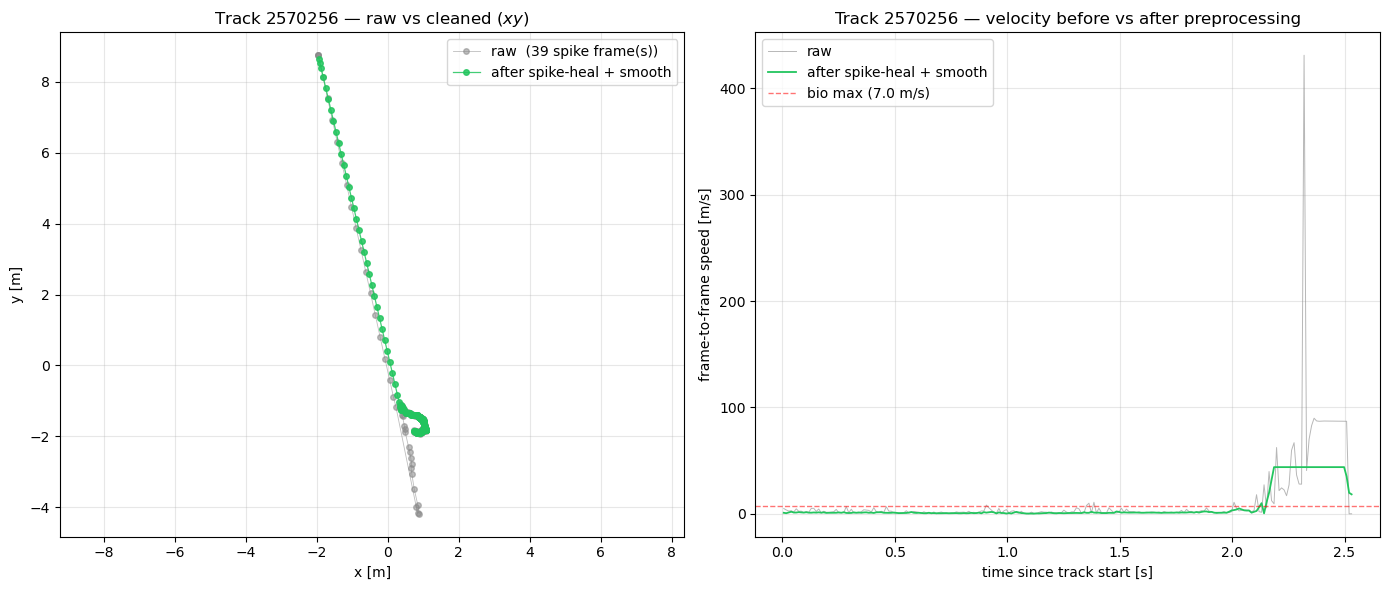

After cleaning: max frame-to-frame speed = 43.88 m/s
               mean speed = 7.18 m/s


In [5]:
# ── apply the same preprocessing as multi_day_pipeline_v3 ──
coords = trk[["posX_insect","posY_insect","posZ_insect"]].astype(float).copy()
spike_mask = np.concatenate([[False], speeds > MAX_BIO_VELOCITY])
coords.loc[spike_mask, :] = np.nan
coords = coords.interpolate(method="linear", limit_direction="both")
smoothed = coords.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()

xx, yy, zz = smoothed["posX_insect"].values, smoothed["posY_insect"].values, smoothed["posZ_insect"].values
speeds_clean = np.linalg.norm(np.diff(smoothed.values, axis=0), axis=1) / dt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# trajectory comparison (xy)
ax = axes[0]
ax.plot(x,  y,  "-o", color="#888888", markersize=4, linewidth=0.6, alpha=0.55,
        label=f"raw  ({n_spikes} spike frame(s))")
ax.plot(xx, yy, "-o", color="#22C55E", markersize=4, linewidth=0.9, alpha=0.85,
        label="after spike-heal + smooth")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"Track {TARGET_UID} — raw vs cleaned ($xy$)")
ax.legend(); ax.set_aspect("equal", adjustable="datalim"); ax.grid(alpha=0.3)

# velocity comparison
ax = axes[1]
ax.plot(mid_t, speeds,       "-", color="#888888", linewidth=0.7, alpha=0.6, label="raw")
ax.plot(mid_t, speeds_clean, "-", color="#22C55E", linewidth=1.3,
        label="after spike-heal + smooth")
ax.axhline(MAX_BIO_VELOCITY, color="red", linestyle="--", linewidth=1.0,
           alpha=0.55, label=f"bio max ({MAX_BIO_VELOCITY} m/s)")
ax.set_xlabel("time since track start [s]")
ax.set_ylabel("frame-to-frame speed [m/s]")
ax.set_title(f"Track {TARGET_UID} — velocity before vs after preprocessing")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"After cleaning: max frame-to-frame speed = {speeds_clean.max():.2f} m/s")
print(f"               mean speed = {np.nanmean(speeds_clean):.2f} m/s")


## 5. (Optional) Track drop-out example

A different artefact: a track that disappeared for a few frames mid-flight.
Useful as a second figure if the bridge subsection wants to illustrate
gap handling separately from spike handling. Skipped by default; uncomment
to run.

In [6]:
# ── identify a track with the longest internal frame gap ──
# (a gap = consecutive elapsed values differing by more than ~3 frame-periods)
# Skipped by default — uncomment to run.

# GAP_THR_S = 3.0 / FPS   # > 3 frames missing
# longest_gap = {}
# for uid, g in ft.groupby("detection_uid"):
#     g = g.sort_values("elapsed")
#     dts = np.diff(g["elapsed"].values)
#     longest_gap[uid] = float(dts.max()) if len(dts) else 0.0
# gap_series = pd.Series(longest_gap).sort_values(ascending=False)
# print("Top 10 tracks by longest internal frame gap:")
# print(gap_series.head(10).round(3))
